In [27]:
!whoami
!echo 24BAD405

nishanth\nishanth
24BAD405


# MovieLens KNN-Based Collaborative Filtering

In [2]:
TARGET_USER = 1
TOP_N_USERS = 10
TOP_N_RECS  = 10

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully')

Libraries imported successfully


In [4]:
df = pd.read_csv(
    r'..\data\u.data',
    sep='\t',
    names=['user_id', 'item_id', 'rating', 'timestamp']
)
print(f'Dataset loaded  →  shape: {df.shape}')
df.head()

Dataset loaded  →  shape: (100000, 4)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
print('── Info ─────────────────────────')
df.info()
print('\n── Describe ──────────────────────')
print(df.describe().round(2))
print('\n── Missing values ────────────────')
print(df.isnull().sum())
print('\n── Unique counts ─────────────────')
print(f'Users : {df["user_id"].nunique()}')
print(f'Items : {df["item_id"].nunique()}')
print(f'Rating range: {df["rating"].min()} – {df["rating"].max()}')

── Info ─────────────────────────
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB

── Describe ──────────────────────
         user_id    item_id     rating     timestamp
count  100000.00  100000.00  100000.00  1.000000e+05
mean      462.48     425.53       3.53  8.835289e+08
std       266.61     330.80       1.13  5.343856e+06
min         1.00       1.00       1.00  8.747247e+08
25%       254.00     175.00       3.00  8.794487e+08
50%       447.00     322.00       4.00  8.828269e+08
75%       682.00     631.00       4.00  8.882600e+08
max       943.00    1682.00       5.00  8.932866e+08

── Missing values ────────────────
user_id      0
item_id      0
rating       0
ti

In [6]:
user_item_matrix = df.pivot_table(
    index='user_id', columns='item_id', values='rating'
)
total_cells  = user_item_matrix.shape[0] * user_item_matrix.shape[1]
filled_cells = user_item_matrix.count().sum()
sparsity     = 1 - filled_cells / total_cells
print(f'Matrix shape : {user_item_matrix.shape}')
print(f'Sparsity     : {sparsity:.4%}')
user_item_matrix.iloc[:5, :8]

Matrix shape : (943, 1682)
Sparsity     : 93.6953%


item_id,1,2,3,4,5,6,7,8
user_id,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
user_item_filled = user_item_matrix.fillna(0)
print(f' NaN filled with 0  →  shape: {user_item_filled.shape}')

# Alternative: per-user mean fill (shown for reference)
user_item_mean_filled = user_item_matrix.apply(lambda row: row.fillna(row.mean()), axis=1)
print('   (Mean-fill version also computed as user_item_mean_filled)')

 NaN filled with 0  →  shape: (943, 1682)
   (Mean-fill version also computed as user_item_mean_filled)


In [8]:
user_similarity    = cosine_similarity(user_item_filled)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)
print(f'Similarity matrix shape: {user_similarity_df.shape}')
print(f'Sample (users 1-5):')
user_similarity_df.iloc[:5, :5].round(3)

Similarity matrix shape: (943, 943)
Sample (users 1-5):


user_id,1,2,3,4,5
user_id,,,,,
1,1.000,0.167,0.047,0.064,0.378
2,0.167,1.000,0.111,0.178,0.073
3,0.047,0.111,1.000,0.344,0.021
4,0.064,0.178,0.344,1.000,0.032
5,0.378,0.073,0.021,0.032,1.000


In [9]:
def get_top_n_similar_users(target_user, similarity_df, n=10):
    """Return top-N users most similar to target_user (excluding self)."""
    sim_scores = similarity_df[target_user].drop(target_user)
    return sim_scores.nlargest(n)

top_similar = get_top_n_similar_users(TARGET_USER, user_similarity_df, TOP_N_USERS)
print(f'Top-{TOP_N_USERS} users similar to User {TARGET_USER}:')
print(top_similar.round(4).to_frame(name='Cosine Similarity'))

Top-10 users similar to User 1:
         Cosine Similarity
user_id                   
916                 0.5691
864                 0.5475
268                 0.5421
92                  0.5405
435                 0.5387
457                 0.5385
738                 0.5270
429                 0.5259
303                 0.5257
276                 0.5245


In [10]:
def predict_ratings(target_user, user_item_matrix, user_similarity_df, n_neighbors=10):
    """
    Weighted average of top-N neighbour ratings for every
    movie the target user has NOT yet rated.
    """
    similar_users  = get_top_n_similar_users(target_user, user_similarity_df, n=n_neighbors)
    target_ratings = user_item_matrix.loc[target_user]
    unrated_items  = target_ratings[target_ratings.isna()].index

    predictions = {}
    for item in unrated_items:
        neighbor_ratings = user_item_matrix.loc[similar_users.index, item].dropna()
        if len(neighbor_ratings) == 0:
            continue
        weights      = similar_users.loc[neighbor_ratings.index]
        weighted_sum = (neighbor_ratings * weights).sum()
        weight_total = weights.abs().sum()
        if weight_total > 0:
            predictions[item] = weighted_sum / weight_total

    return pd.Series(predictions).sort_values(ascending=False)

predicted = predict_ratings(TARGET_USER, user_item_matrix, user_similarity_df)
print(f'Top-20 predicted ratings for User {TARGET_USER}:')
predicted.head(20).round(3).to_frame(name='Predicted Rating')

Top-20 predicted ratings for User 1:


,Predicted Rating
483,5.000
1168,5.000
1009,5.000
1007,5.000
963,5.000
736,5.000
853,5.000
1019,5.000
632,5.000
512,5.000


In [11]:
def get_top_n_recommendations(target_user, user_item_matrix,
                            user_similarity_df, n_recommendations=10,
                            n_neighbors=10):
    preds = predict_ratings(target_user, user_item_matrix,
                            user_similarity_df, n_neighbors)
    return preds.head(n_recommendations)

recommendations = get_top_n_recommendations(
    TARGET_USER, user_item_matrix, user_similarity_df,
    n_recommendations=TOP_N_RECS
)
print(f'\n Top-{TOP_N_RECS} Movie Recommendations for User {TARGET_USER}:')
print('-' * 45)
for rank, (item_id, pred_rating) in enumerate(recommendations.items(), 1):
    print(f'  {rank:2d}. Movie ID {item_id:5d}  →  Predicted Rating: {pred_rating:.3f}')


 Top-10 Movie Recommendations for User 1:
---------------------------------------------
   1. Movie ID   483  →  Predicted Rating: 5.000
   2. Movie ID  1168  →  Predicted Rating: 5.000
   3. Movie ID  1009  →  Predicted Rating: 5.000
   4. Movie ID  1007  →  Predicted Rating: 5.000
   5. Movie ID   963  →  Predicted Rating: 5.000
   6. Movie ID   736  →  Predicted Rating: 5.000
   7. Movie ID   853  →  Predicted Rating: 5.000
   8. Movie ID  1019  →  Predicted Rating: 5.000
   9. Movie ID   632  →  Predicted Rating: 5.000
  10. Movie ID   512  →  Predicted Rating: 5.000


In [12]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_matrix = train_df.pivot_table(
    index='user_id', columns='item_id', values='rating'
).fillna(0)

train_sim    = cosine_similarity(train_matrix)
train_sim_df = pd.DataFrame(train_sim,
                            index=train_matrix.index,
                            columns=train_matrix.index)

actuals, predicted_vals = [], []
print('Computing predictions on test set …')
for _, row in test_df.iterrows():
    u, i, r = int(row['user_id']), int(row['item_id']), row['rating']
    if u not in train_sim_df.index or i not in train_matrix.columns:
        continue
    sim_users = get_top_n_similar_users(u, train_sim_df, TOP_N_USERS)
    nbr_ratings = train_matrix.loc[
        sim_users.index[sim_users.index.isin(train_matrix.index)], i]
    nbr_ratings = nbr_ratings[nbr_ratings > 0]
    if len(nbr_ratings) == 0:
        continue
    w = sim_users.loc[nbr_ratings.index]
    w_sum = (nbr_ratings * w).sum()
    w_tot = w.abs().sum()
    if w_tot > 0:
        actuals.append(r)
        predicted_vals.append(w_sum / w_tot)

actuals        = np.array(actuals)
predicted_vals = np.array(predicted_vals)
rmse = np.sqrt(mean_squared_error(actuals, predicted_vals))
mae  = mean_absolute_error(actuals, predicted_vals)

print(f'\n  RMSE            : {rmse:.4f}')
print(f'  MAE             : {mae:.4f}')
print(f'  Test samples    : {len(actuals):,}')

Computing predictions on test set …

  RMSE            : 1.1077
  MAE             : 0.8604
  Test samples    : 17,944


##  Analysis & Visualizations

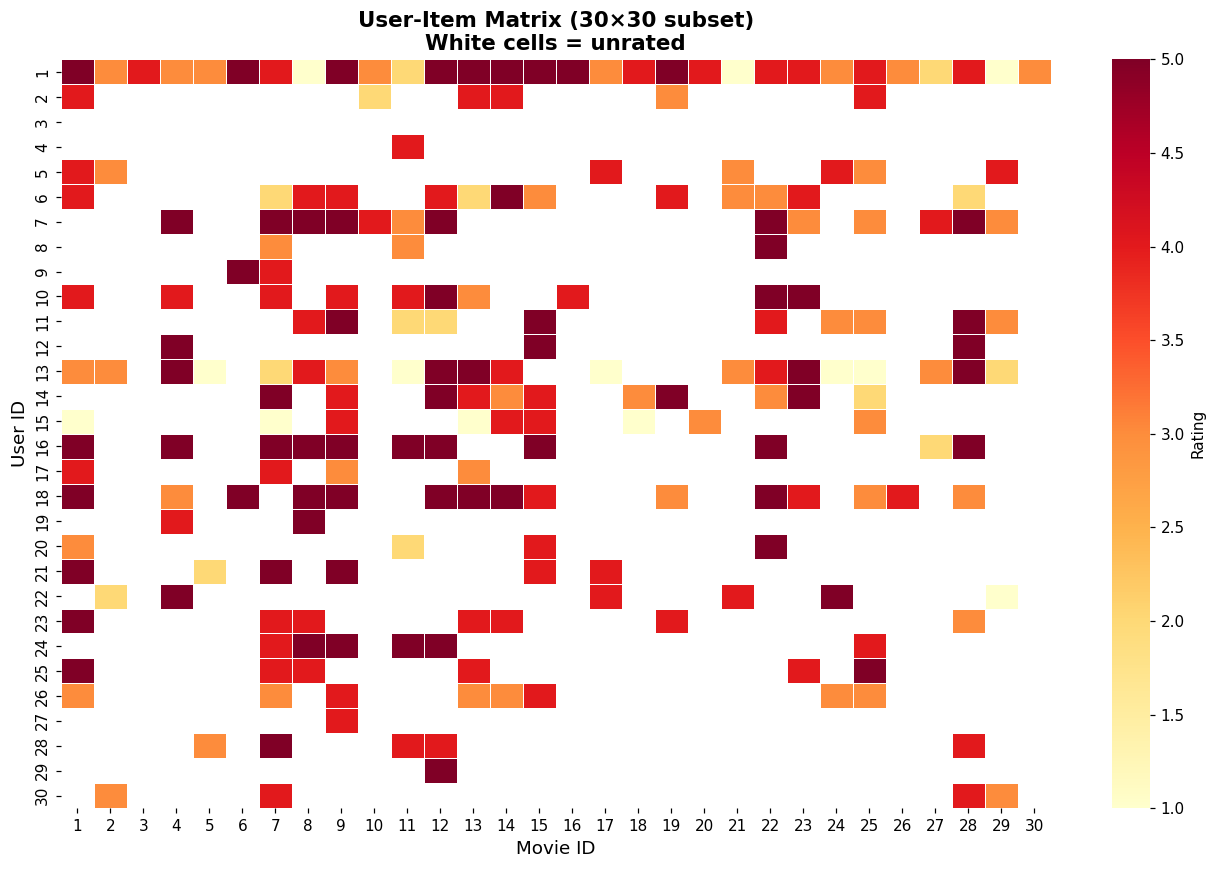

In [ ]:
subset = user_item_matrix.iloc[:30, :30]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(subset, ax=ax, cmap='YlOrRd', linewidths=0.4,
            cbar_kws={'label': 'Rating'}, mask=subset.isna())
ax.set_title('User-Item Matrix (30×30 subset)\nWhite cells = unrated', fontsize=14, fontweight='bold')
ax.set_xlabel('Movie ID', fontsize=12)
ax.set_ylabel('User ID', fontsize=12)
plt.tight_layout()
plt.show()

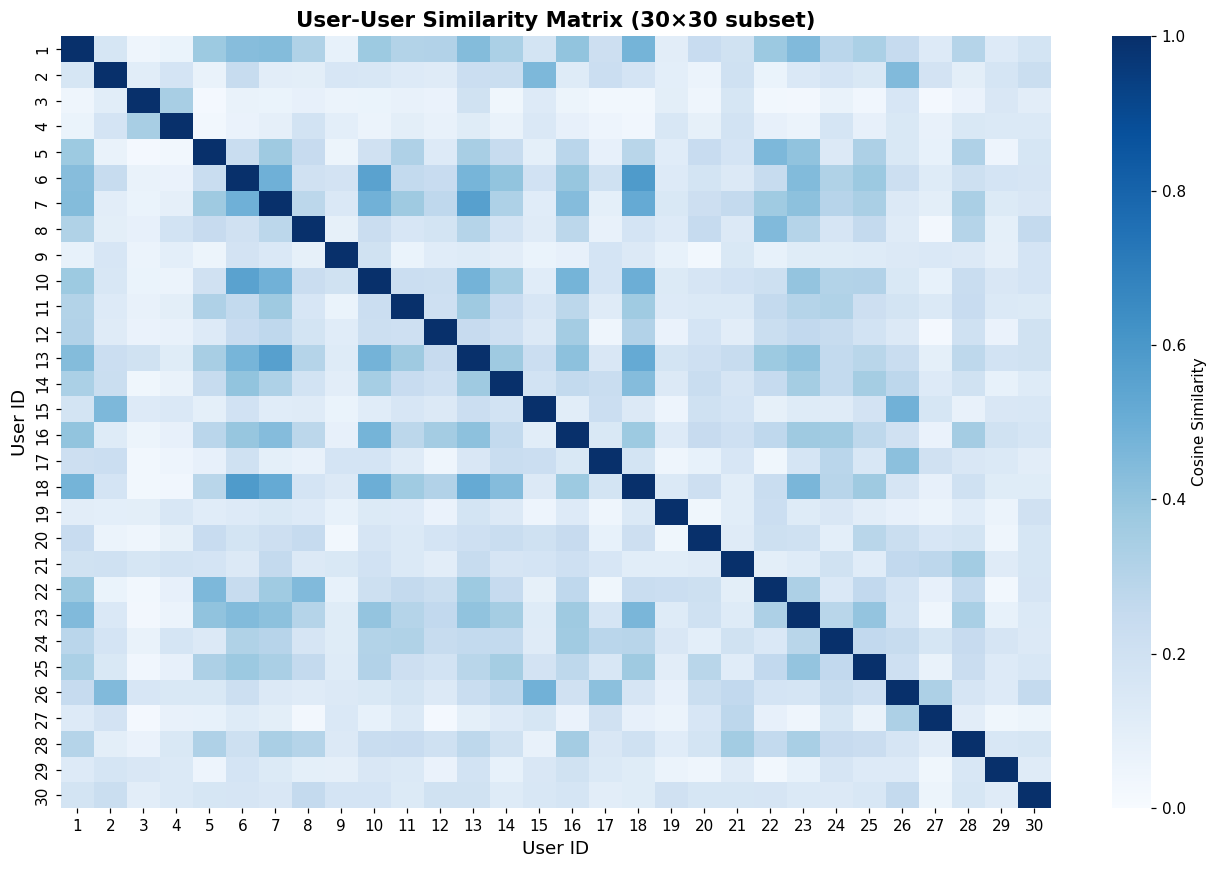

In [ ]:
sim_subset = user_similarity_df.iloc[:30, :30]
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(sim_subset, ax=ax, cmap='Blues', vmin=0, vmax=1,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('User-User Similarity Matrix (30×30 subset)', fontsize=14, fontweight='bold')
ax.set_xlabel('User ID', fontsize=12)
ax.set_ylabel('User ID', fontsize=12)
plt.tight_layout()
plt.show()

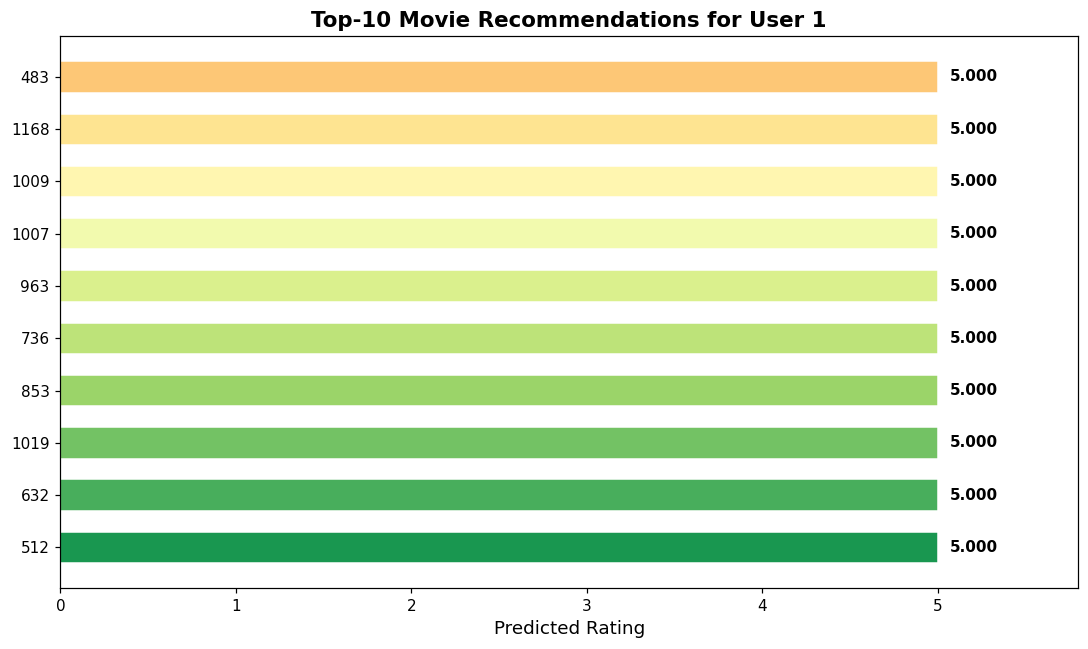

In [ ]:
rec_items  = recommendations.index.astype(str)
rec_scores = recommendations.values
colors     = plt.cm.RdYlGn(np.linspace(0.35, 0.9, len(rec_scores)))
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(rec_items[::-1], rec_scores[::-1], color=colors[::-1], edgecolor='white', height=0.6)
ax.set_xlabel('Predicted Rating', fontsize=12)
ax.set_title(f'Top-{TOP_N_RECS} Movie Recommendations for User {TARGET_USER}', fontsize=14, fontweight='bold')
ax.set_xlim(0, 5.8)
for bar, val in zip(bars, rec_scores[::-1]):
    ax.text(bar.get_width() + 0.07, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

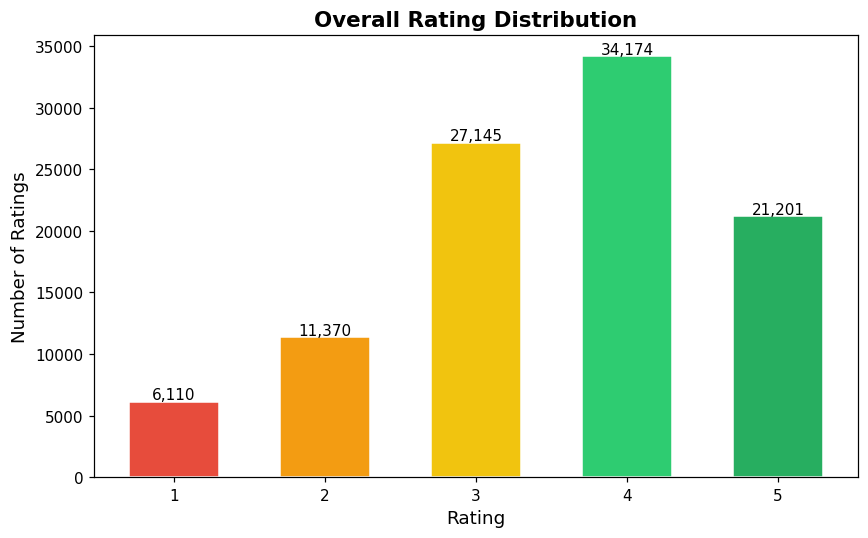

In [ ]:
rating_counts = df['rating'].value_counts().sort_index()
pal = ['#e74c3c','#f39c12','#f1c40f','#2ecc71','#27ae60']
fig, ax = plt.subplots(figsize=(8, 5))
bars2 = ax.bar(rating_counts.index, rating_counts.values, color=pal, edgecolor='white', width=0.6)
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Ratings', fontsize=12)
ax.set_title('Overall Rating Distribution', fontsize=14, fontweight='bold')
for bar, (x, y) in zip(bars2, zip(rating_counts.index, rating_counts.values)):
    ax.text(x, y + 200, f'{y:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

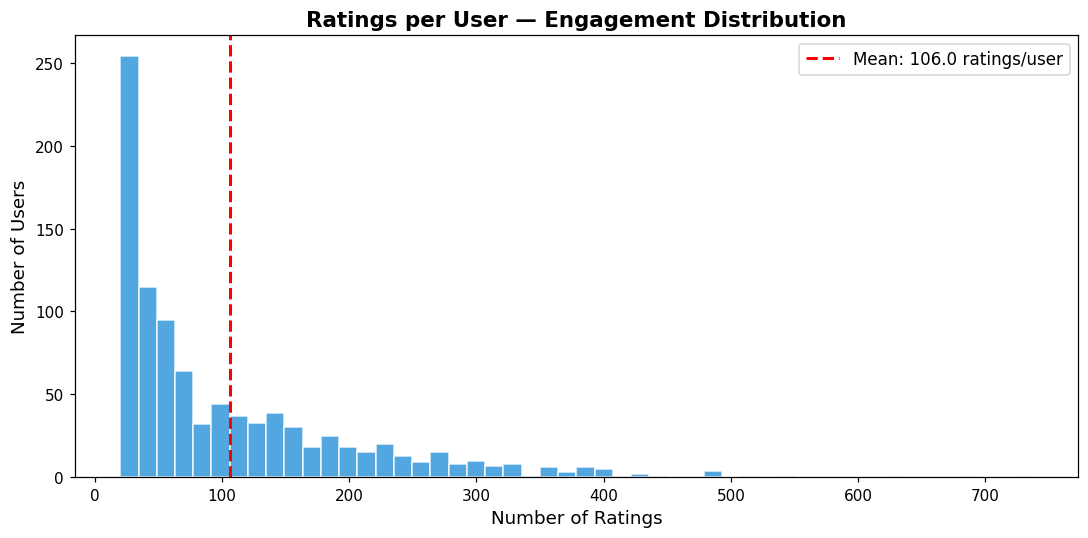

In [ ]:
# ── Plot 5 : Ratings per User Distribution ─────────────────
ratings_per_user = df.groupby('user_id')['item_id'].count()
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ratings_per_user, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
ax.axvline(ratings_per_user.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {ratings_per_user.mean():.1f} ratings/user')
ax.set_xlabel('Number of Ratings', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title('Ratings per User — Engagement Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

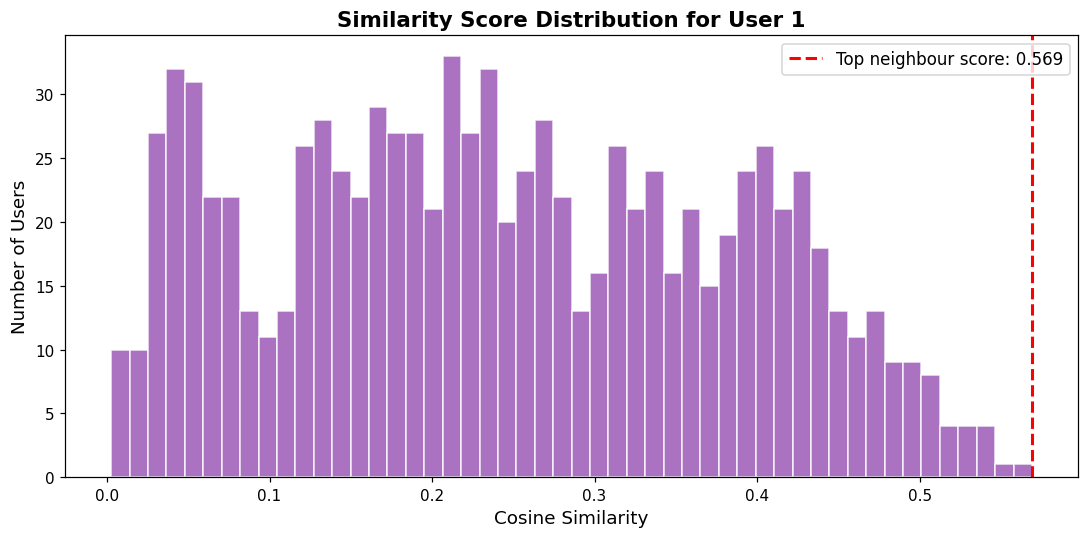

In [ ]:
target_sims = user_similarity_df[TARGET_USER].drop(TARGET_USER)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(target_sims, bins=50, color='#9b59b6', edgecolor='white', alpha=0.85)
ax.axvline(top_similar.values[0], color='red', linestyle='--', linewidth=2,
        label=f'Top neighbour score: {top_similar.values[0]:.3f}')
ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.set_title(f'Similarity Score Distribution for User {TARGET_USER}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

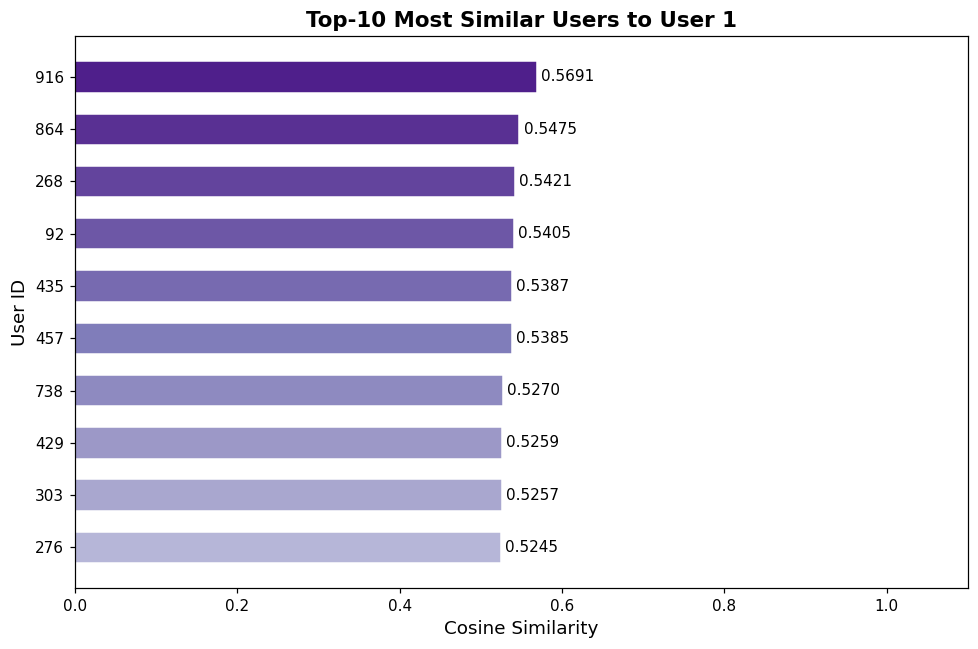

In [ ]:
top_sim_sorted = top_similar.sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_sim_sorted.index.astype(str), top_sim_sorted.values,
        color=plt.cm.Purples(np.linspace(0.4, 0.9, len(top_sim_sorted))),
        edgecolor='white', height=0.6)
for i, (uid, val) in enumerate(zip(top_sim_sorted.index, top_sim_sorted.values)):
    ax.text(val + 0.005, i, f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('User ID', fontsize=12)
ax.set_title(f'Top-{TOP_N_USERS} Most Similar Users to User {TARGET_USER}', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.1)
plt.tight_layout()
plt.show()

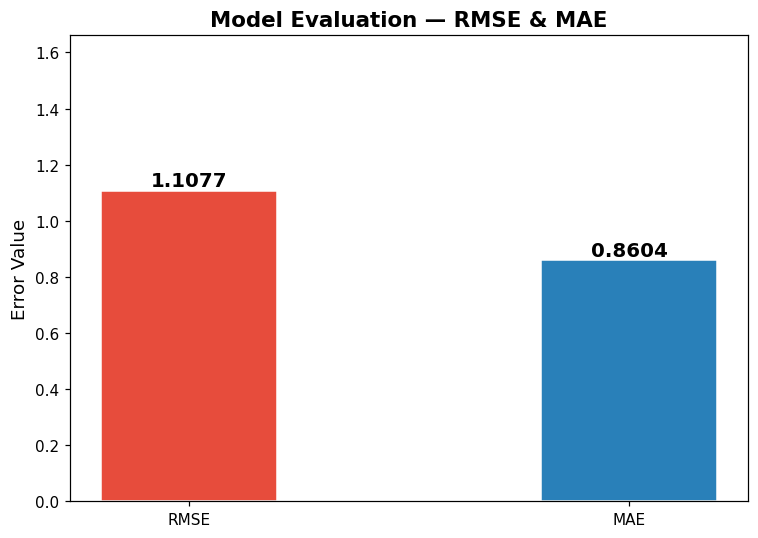

In [ ]:
# ── Plot 8 : RMSE vs MAE Evaluation Metrics ────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars3 = ax.bar(['RMSE', 'MAE'], [rmse, mae],
               color=['#e74c3c', '#2980b9'], width=0.4, edgecolor='white')
ax.set_ylim(0, max(rmse, mae) * 1.5)
ax.set_ylabel('Error Value', fontsize=12)
ax.set_title('Model Evaluation — RMSE & MAE', fontsize=14, fontweight='bold')
for bar, val in zip(bars3, [rmse, mae]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{val:.4f}', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

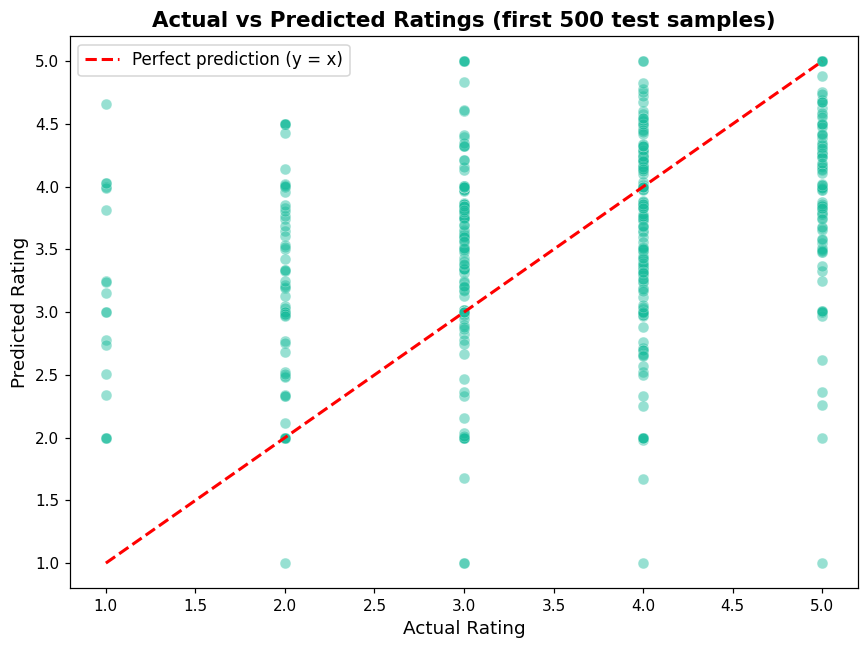

In [ ]:
# ── Plot 9 : Actual vs Predicted Ratings ───────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(actuals[:500], predicted_vals[:500], alpha=0.45,
           color='#1abc9c', edgecolors='white', linewidths=0.3, s=50)
ax.plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect prediction (y = x)')
ax.set_xlabel('Actual Rating', fontsize=12)
ax.set_ylabel('Predicted Rating', fontsize=12)
ax.set_title('Actual vs Predicted Ratings (first 500 test samples)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
# ── Final Summary ────────────────────────────────────────────
print('=' * 55)
print('  MOVIELENS KNN RECOMMENDATION — SUMMARY')
print('=' * 55)
print(f'  Target User    : {TARGET_USER}')
print(f'  Dataset        : 100,000 ratings | 943 users | 1,682 movies')
print(f'  Sparsity       : {sparsity:.2%}')
print(f'  RMSE           : {rmse:.4f}')
print(f'  MAE            : {mae:.4f}')
print(f'  Top-{TOP_N_RECS} recs  : Movie IDs {list(recommendations.index)}')
print('=' * 55)

  MOVIELENS KNN RECOMMENDATION — SUMMARY
  Target User    : 1
  Dataset        : 100,000 ratings | 943 users | 1,682 movies
  Sparsity       : 93.70%
  RMSE           : 1.1077
  MAE            : 0.8604
  Top-10 recs  : Movie IDs [483, 1168, 1009, 1007, 963, 736, 853, 1019, 632, 512]
